<a href="https://colab.research.google.com/github/RobertDS-45/Money_Remmitence_analysis/blob/main/Bot_Money_remmitence_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import files
import pandas as pd

# Upload the file
uploaded = files.upload()

# Assuming the user uploads 'Money_Remittance_transactions_2025.csv'
# You can then read it into a pandas DataFrame
for fn in uploaded.keys():
    print(f'User uploaded file "{fn}"')
    df = pd.read_csv(fn)
    display(df.head())


Saving Money_Remittance_transactions_2025.csv to Money_Remittance_transactions_2025.csv
User uploaded file "Money_Remittance_transactions_2025.csv"


,INSTITUTIONCODE,REPORTINGDATE,DESCRIPTIONNO,COMPANY,INFLOW_VOLUME,INFLOW_VALUE,OUTFLOW_VOLUME,OUTLOW_VALUE
0,Bnk-001,1/31/2025,1,Western Union,"3,745","2,207,540,409",573,"273,899,340"
1,Bnk-001,1/31/2025,2,MoneyGram,"1,941","1,351,849,159",166,"116,292,545"
2,Bnk-001,1/31/2025,3,Travelex,273,"1,071,463,474",22,"108,098,083"
3,Bnk-001,1/31/2025,4,UBA Africash,169,"71,548,144",16,"8,833,937"
4,Bnk-001,1/31/2025,5,Coinstar,0,0,0,0


In [4]:
df.tail()

,INSTITUTIONCODE,REPORTINGDATE,DESCRIPTIONNO,COMPANY,INFLOW_VOLUME,INFLOW_VALUE,OUTFLOW_VOLUME,OUTLOW_VALUE
5035,Bnk-042,12/31/2025,6,Express Money,0,0,0,0
5036,Bnk-042,12/31/2025,7,World Remit,0,0,0,0
5037,Bnk-042,12/31/2025,8,Tanzania Postal Services Inter state,0,0,0,0
5038,Bnk-042,12/31/2025,9,Diaspora Data through Swift,0,0,0,0
5039,Bnk-042,12/31/2025,10,Other Remitance company(s),0,0,0,0


In [5]:
df.describe()

,DESCRIPTIONNO,OUTFLOW_VOLUME
count,5040.000000,5040.000000
mean,5.500000,11.724603
std,2.872566,57.637492
min,1.000000,0.000000
25%,3.000000,0.000000
50%,5.500000,0.000000
75%,8.000000,0.000000
max,10.000000,934.000000


In [6]:
df.columns

Index(['INSTITUTIONCODE', 'REPORTINGDATE', 'DESCRIPTIONNO', 'COMPANY',
       'INFLOW_VOLUME', 'INFLOW_VALUE', 'OUTFLOW_VOLUME', 'OUTLOW_VALUE'],
      dtype='object')

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize']=[12,6]

In [8]:
print("stage 1.1: Loading and cleaning raw data...")
df=pd.read_csv('Money_Remittance_transactions_2025.csv')
df.columns

stage 1.1: Loading and cleaning raw data...


Index(['INSTITUTIONCODE', 'REPORTINGDATE', 'DESCRIPTIONNO', 'COMPANY',
       'INFLOW_VOLUME', 'INFLOW_VALUE', 'OUTFLOW_VOLUME', 'OUTLOW_VALUE'],
      dtype='object')

In [9]:
# fixing header typo
df =df.rename(columns={'OUTLOW_VALUE': 'OUTFLOW_VALUE'})

In [10]:
# clean string formating
num_cols = ['INFLOW_VOLUME', 'INFLOW_VALUE', 'OUTFLOW_VOLUME', 'OUTFLOW_VALUE']
for col in num_cols:
  df[col]= df[col].astype(str).str.replace(',', '', regex=True)
  df[col] = pd.to_numeric(df[col],errors='coerce').fillna(0)

# standadize data format and parse reporting month
df['REPORTINGDATE'] = pd.to_datetime(df['REPORTINGDATE'],errors='coerce')
df['MONTH'] = df['REPORTINGDATE'].dt.month.fillna(0).astype(int)

# create a composite total turnover feature
df['TOTAL_VALUE'] = df['INFLOW_VOLUME'] + df['OUTFLOW_VALUE']
print(f"Data succefully cleaned. shape: {df.shape}")

Data succefully cleaned. shape: (5040, 10)



 Stage 1.2: Generating Visualization for analysis...


/tmp/ipykernel_3314/1478084774.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=monthly_market, x='MONTH',y='TOTAL_VALUE',palette='viridis', legend=False)


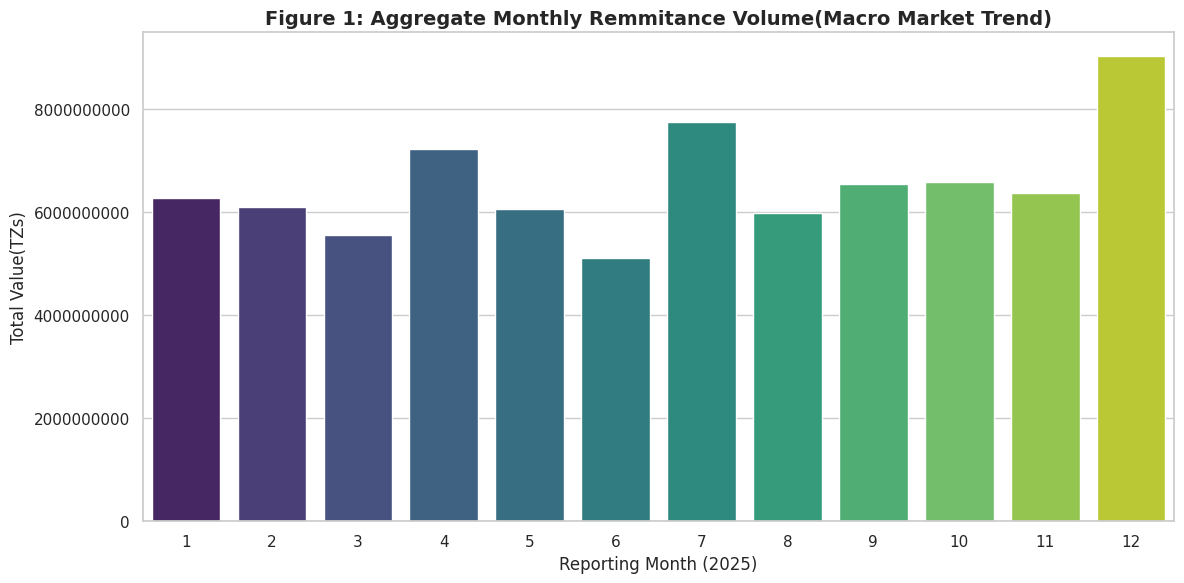

In [11]:
# 1.2 VISUAL DATA EXPLORATION (EDA)
print("\n Stage 1.2: Generating Visualization for analysis...")
# plot A: Market seasonality chek (total Macro Value by Month)
monthly_market = df.groupby('MONTH')['TOTAL_VALUE'].sum().reset_index()

plt.figure()
sns.barplot(data=monthly_market, x='MONTH',y='TOTAL_VALUE',palette='viridis', legend=False)
plt.title('Figure 1: Aggregate Monthly Remmitance Volume(Macro Market Trend)',fontsize=14,fontweight='bold')
plt.xlabel('Reporting Month (2025)',fontsize=12)
plt.ylabel('Total Value(TZs)',fontsize=12)
plt.ticklabel_format(style='plain',axis='y')
plt.tight_layout()
plt.savefig('eda_market_seasonality.png',dpi=300)
plt.show()

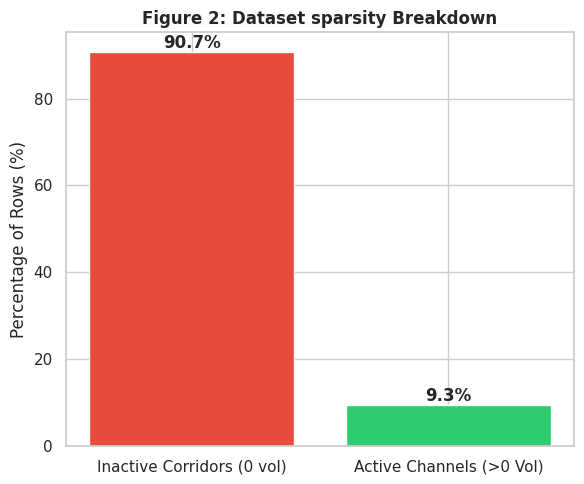

In [12]:
from matplotlib import colors
# PLOT B the sparsity profile (Visualizing the ocean of zero)
sparsity_check = (df['TOTAL_VALUE'] == 0).value_counts(normalize=True)*100

plt.figure(figsize=(6,5))
plt.bar(['Inactive Corridors (0 vol)','Active Channels (>0 Vol)'],sparsity_check.values,color=['#e74c3c','#2ecc71'])
plt.title('Figure 2: Dataset sparsity Breakdown', fontsize=12, fontweight='bold')
plt.ylabel('Percentage of Rows (%)',fontsize=12)
for i, val in enumerate(sparsity_check.values):
  plt.text(i,val + 1, f"{val:.1f}%", ha='center',fontweight='bold')
plt.tight_layout()
plt.savefig('eda_sparsity_check.png',dpi=300)
plt.show()

In [13]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

print("Stage 1: Executing Data Acquisition, Cleaning, and Encoding...")

# Load and rectify schema typos
df = pd.read_csv('Money_Remittance_transactions_2025.csv')
df = df.rename(columns={'OUTLOW_VALUE': 'OUTFLOW_VALUE'})

# Clean string formatting and convert core metrics to numeric
num_cols = ['INFLOW_VOLUME', 'INFLOW_VALUE', 'OUTFLOW_VOLUME', 'OUTFLOW_VALUE']
for col in num_cols:
    df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', '', regex=True), errors='coerce').fillna(0)

# Parse time dimensions and establish baseline turnover
df['REPORTINGDATE'] = pd.to_datetime(df['REPORTINGDATE'], errors='coerce')
df['MONTH'] = df['REPORTINGDATE'].dt.month.fillna(0).astype(int)
df['TOTAL_VALUE'] = df['INFLOW_VALUE'] + df['OUTFLOW_VALUE']

# Encode categorical entities
le_institution = LabelEncoder()
df['INSTITUTION_ENCODED'] = le_institution.fit_transform(df['INSTITUTIONCODE'])

le_company = LabelEncoder()
df['COMPANY_ENCODED'] = le_company.fit_transform(df['COMPANY'])

print(f"Data parsed successfully. Base matrix shape: {df.shape}")
df.head()

Stage 1: Executing Data Acquisition, Cleaning, and Encoding...
Data parsed successfully. Base matrix shape: (5040, 12)


,INSTITUTIONCODE,REPORTINGDATE,DESCRIPTIONNO,COMPANY,INFLOW_VOLUME,INFLOW_VALUE,OUTFLOW_VOLUME,OUTFLOW_VALUE,MONTH,TOTAL_VALUE,INSTITUTION_ENCODED,COMPANY_ENCODED
0,Bnk-001,2025-01-31,1,Western Union,3745,2207540409,573,273899340,1,2481439749,0,8
1,Bnk-001,2025-01-31,2,MoneyGram,1941,1351849159,166,116292545,1,1468141704,0,3
2,Bnk-001,2025-01-31,3,Travelex,273,1071463474,22,108098083,1,1179561557,0,6
3,Bnk-001,2025-01-31,4,UBA Africash,169,71548144,16,8833937,1,80382081,0,7
4,Bnk-001,2025-01-31,5,Coinstar,0,0,0,0,1,0,0,0


In [ ]:
!pip install sdv

In [16]:
from sdv.single_table import GaussianCopulaSynthesizer
from sdv.metadata import SingleTableMetadata

print("Stage 2: Calculating Real Ratios & Scaling Active Matrix via SDV...")

# 1. Feature Engineering on real data
df['INFLOW_AVG_VAL'] = np.where(df['INFLOW_VOLUME'] > 0, df['INFLOW_VALUE'] / df['INFLOW_VOLUME'], 0)
df['OUTFLOW_AVG_VAL'] = np.where(df['OUTFLOW_VOLUME'] > 0, df['OUTFLOW_VALUE'] / df['OUTFLOW_VOLUME'], 0)
df['NET_FLOW_VALUE'] = df['INFLOW_VALUE'] - df['OUTFLOW_VALUE']
df['IS_ACTIVE'] = np.where(df['TOTAL_VALUE'] > 0, 1, 0)

# Real data peer group scaling
monthly_market_totals = df.groupby('MONTH')['TOTAL_VALUE'].transform('sum')
df['MONTHLY_MARKET_SHARE'] = np.where(monthly_market_totals > 0, df['TOTAL_VALUE'] / monthly_market_totals, 0)

active_mask = df['IS_ACTIVE'] == 1
df['MONTHLY_VALUE_ZSCORE'] = 0.0
if active_mask.any():
    means = df[active_mask].groupby('MONTH')['TOTAL_VALUE'].transform('mean')
    stds = df[active_mask].groupby('MONTH')['TOTAL_VALUE'].transform('std').replace(0, 1)
    df.loc[active_mask, 'MONTHLY_VALUE_ZSCORE'] = (df.loc[active_mask, 'TOTAL_VALUE'] - means) / stds

# 2. Run SDV Pipeline on Active Channels
active_df = df[df['IS_ACTIVE'] == 1].copy()
train_data = active_df.drop(columns=['REPORTINGDATE'])

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(data=train_data)

synthesizer = GaussianCopulaSynthesizer(metadata)
synthesizer.fit(train_data)

print("Sampling 100,000 synthetic baseline rows...")
synthetic_active = synthesizer.sample(num_rows=100000)

# 3. Post-Synthesis Alignment & Re-calculation
synthetic_active['INFLOW_VOLUME'] = synthetic_active['INFLOW_VOLUME'].clip(lower=0).round().astype(int)
synthetic_active['OUTFLOW_VOLUME'] = synthetic_active['OUTFLOW_VOLUME'].clip(lower=0).round().astype(int)
synthetic_active['INFLOW_VALUE'] = synthetic_active['INFLOW_VALUE'].clip(lower=0)
synthetic_active['OUTFLOW_VALUE'] = synthetic_active['OUTFLOW_VALUE'].clip(lower=0)

synthetic_active['TOTAL_VALUE'] = synthetic_active['INFLOW_VALUE'] + synthetic_active['OUTFLOW_VALUE']
synthetic_active['NET_FLOW_VALUE'] = synthetic_active['INFLOW_VALUE'] - synthetic_active['OUTFLOW_VALUE']
synthetic_active['INFLOW_AVG_VAL'] = np.where(synthetic_active['INFLOW_VOLUME'] > 0, synthetic_active['INFLOW_VALUE'] / synthetic_active['INFLOW_VOLUME'], 0)
synthetic_active['OUTFLOW_AVG_VAL'] = np.where(synthetic_active['OUTFLOW_VOLUME'] > 0, synthetic_active['OUTFLOW_VALUE'] / synthetic_active['OUTFLOW_VOLUME'], 0)

synth_market_totals = synthetic_active.groupby('MONTH')['TOTAL_VALUE'].transform('sum')
synthetic_active['MONTHLY_MARKET_SHARE'] = np.where(synth_market_totals > 0, synthetic_active['TOTAL_VALUE'] / synth_market_totals, 0)

synth_means = synthetic_active.groupby('MONTH')['TOTAL_VALUE'].transform('mean')
synth_stds = synthetic_active.groupby('MONTH')['TOTAL_VALUE'].transform('std').replace(0, 1)
synthetic_active['MONTHLY_VALUE_ZSCORE'] = (synthetic_active['TOTAL_VALUE'] - synth_means) / synth_stds

print("Synthesis layer compiled successfully.")

Stage 2: Calculating Real Ratios & Scaling Active Matrix via SDV...


/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:183: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:139: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


Sampling 100,000 synthetic baseline rows...
Synthesis layer compiled successfully.


In [17]:
df.describe()

,REPORTINGDATE,DESCRIPTIONNO,INFLOW_VOLUME,INFLOW_VALUE,OUTFLOW_VOLUME,OUTFLOW_VALUE,MONTH,TOTAL_VALUE,INSTITUTION_ENCODED,COMPANY_ENCODED,INFLOW_AVG_VAL,OUTFLOW_AVG_VAL,NET_FLOW_VALUE,IS_ACTIVE,MONTHLY_MARKET_SHARE,MONTHLY_VALUE_ZSCORE
count,5040,5040.000000,5040.000000,5.040000e+03,5040.000000,5.040000e+03,5040.000000,5.040000e+03,5040.000000,5040.000000,5.040000e+03,5.040000e+03,5.040000e+03,5040.000000,5040.000000,5.040000e+03
mean,2025-07-15 22:00:00,5.500000,87.569444,9.453491e+07,11.724603,1.558992e+07,6.500000,1.101248e+08,20.500000,4.500000,2.524435e+05,3.462505e+05,7.894498e+07,0.092857,0.002381,-2.588318e-18
min,2025-01-31 00:00:00,1.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,1.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,-1.089446e+00
25%,2025-04-22 12:00:00,3.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,3.750000,0.000000e+00,10.000000,2.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00
50%,2025-07-15 12:00:00,5.500000,0.000000,0.000000e+00,0.000000,0.000000e+00,6.500000,0.000000e+00,20.500000,4.500000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00
75%,2025-10-07 18:00:00,8.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,9.250000,0.000000e+00,31.000000,7.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00
max,2025-12-31 00:00:00,10.000000,5676.000000,6.407443e+09,934.000000,1.313219e+09,12.000000,7.720662e+09,41.000000,9.000000,1.197251e+07,1.771022e+07,5.094225e+09,1.000000,0.143061,4.406432e+00
std,NaN,2.872566,408.443759,4.257508e+08,57.637492,7.346364e+07,3.452395,4.929966e+08,12.122121,2.872566,1.338563e+06,1.899270e+06,3.609371e+08,0.290261,0.010538,3.008224e-01


### Computing Ensemble Anomaly Scores and Votes

To analyze fraud yield based on different `ENSEMBLE_VOTES` thresholds, we need to first compute these scores. This cell replicates the multi-seed Isolation Forest ensemble logic from your `pipe_line.py` to generate `RAW_ANOMALY_SCORE`, `ENSEMBLE_VOTES`, and `ANOMALY_CONFIDENCE` for each transaction.

This will allow us to assess how different gating criteria would have impacted the pseudo-label generation for your XGBoost model.

In [18]:
from sklearn.ensemble import IsolationForest

print("\n[ENSEMBLE COMPUTATION] Starting multi-seed Isolation Forest ensemble with Synthetic Baseline...")

# Define features for multidimensional isolation
preliminary_features = ['MONTHLY_VALUE_ZSCORE', 'MONTHLY_MARKET_SHARE', 'NET_FLOW_VALUE', 'INFLOW_AVG_VAL', 'OUTFLOW_AVG_VAL']
adaptive_contamination = 0.035
seeds = [42, 101, 202, 303, 404]

# Initialize score tracking matrix specifically for your real active rows
all_scores_matrix = np.zeros((len(active_df), len(seeds)))

# FIX: Initialize the list to store the 5 full Isolation Forest models for deployment
isolation_models = []

for idx, seed in enumerate(seeds):
    iso = IsolationForest(
        n_estimators=200,
        contamination=adaptive_contamination,
        random_state=seed,
        max_samples="auto",
        bootstrap=True,
        n_jobs=-1
    )

    # 1. FIT the model using the large 100,000 synthetic dataset profile
    print(f" -> Training model with seed {seed} on synthetic data bounds...")
    iso.fit(synthetic_active[preliminary_features].fillna(0.0))

    # FIX: Append the actual trained model instance to our deployment list
    isolation_models.append(iso)

    # 2. SCORE the actual real active records (active_df) against that profile
    all_scores_matrix[:, idx] = -iso.score_samples(active_df[preliminary_features].fillna(0.0))

# 3. Calculate metrics directly on your real active rows
active_df['RAW_ANOMALY_SCORE'] = np.mean(all_scores_matrix, axis=1)
active_df['MEDIAN_ANOMALY_SCORE'] = np.median(all_scores_matrix, axis=1)
active_df['SD_ANOMALY_SCORE'] = np.std(all_scores_matrix, axis=1)

# 4. Consensus Voting (Calculates threshold based on the real scores population)
vote_matrix = np.zeros_like(all_scores_matrix)
for i in range(len(seeds)):
    relevant_scores = all_scores_matrix[:, i]
    threshold = np.percentile(relevant_scores, 97) # Flag top 3% per seed
    vote_matrix[:, i] = (relevant_scores >= threshold).astype(int)

active_df['ENSEMBLE_VOTES'] = vote_matrix.sum(axis=1)

# 5. Calculate Final Anomaly Confidence
max_sd = active_df["SD_ANOMALY_SCORE"].max()
if max_sd == 0 or np.isnan(max_sd):
    max_sd = 1.0

stability_score = (1.0 - (active_df["SD_ANOMALY_SCORE"] / max_sd))
vote_score = (active_df["ENSEMBLE_VOTES"] / len(seeds))
active_df['ANOMALY_CONFIDENCE'] = (0.4 * stability_score + 0.6 * vote_score)

# 6. Generate final pseudo-label based on strong consensus (e.g., at least 3 out of 5 models agree)
active_df['FRAUD_LABEL'] = np.where(active_df['ENSEMBLE_VOTES'] >= 3, 1, 0)

print("[ENSEMBLE COMPUTATION] Multi-seed ensemble on real active data completed.")

# Display summary metrics
print("\nEnsemble Score Summary (Real Active Records):")
display(active_df[['RAW_ANOMALY_SCORE', 'ENSEMBLE_VOTES', 'ANOMALY_CONFIDENCE']].describe())


[ENSEMBLE COMPUTATION] Starting multi-seed Isolation Forest ensemble with Synthetic Baseline...
 -> Training model with seed 42 on synthetic data bounds...
 -> Training model with seed 101 on synthetic data bounds...
 -> Training model with seed 202 on synthetic data bounds...
 -> Training model with seed 303 on synthetic data bounds...
 -> Training model with seed 404 on synthetic data bounds...
[ENSEMBLE COMPUTATION] Multi-seed ensemble on real active data completed.

Ensemble Score Summary (Real Active Records):


,RAW_ANOMALY_SCORE,ENSEMBLE_VOTES,ANOMALY_CONFIDENCE
count,468.000000,468.000000,468.000000
mean,0.714310,0.160256,0.095205
std,0.010044,0.836763,0.113280
min,0.704014,0.000000,0.000000
25%,0.707536,0.000000,0.052924
50%,0.709805,0.000000,0.077317
75%,0.718355,0.000000,0.097051
max,0.758314,5.000000,0.809902


### Fraud Yield Analysis for Different `ENSEMBLE_VOTES` Thresholds

Now that we have computed `ENSEMBLE_VOTES` for each record, we can calculate the fraud yield percentage for various thresholds. This analysis will help you understand how relaxing or tightening the `ENSEMBLE_VOTES` condition (part of your `fraud_condition` in `pipe_line.py`) impacts the number of records considered as high-confidence fraud. This is crucial for addressing the 'Insufficient variance' issue.

In [19]:
print("\n[FRAUD YIELD ANALYSIS] Calculating fraud yield for different ENSEMBLE_VOTES thresholds...")

# Filter for active records, using our updated active_df tracking variable
total_active_records = len(active_df)

if total_active_records == 0:
    print("No active records found for analysis.")
else:
    print(f"Total Active Records: {total_active_records}")
    results = []

    # Iterate through possible ENSEMBLE_VOTES thresholds (0 to 5)
    for threshold in range(0, len(seeds) + 1):
        # Scan ensemble votes calculated from our synthetic-trained models
        fraud_yield_mask = (active_df['ENSEMBLE_VOTES'] >= threshold)
        fraud_yield_count = fraud_yield_mask.sum()
        fraud_yield_percentage = (fraud_yield_count / total_active_records) * 100

        results.append({
            'ENSEMBLE_VOTES Threshold': threshold,
            'Fraud Records Count': fraud_yield_count,
            'Fraud Yield Percentage': f'{fraud_yield_percentage:.2f}%'
        })

    results_df = pd.DataFrame(results)
    display(results_df)

    print("\n[FRAUD YIELD ANALYSIS] Analysis complete. Use these thresholds to adjust your gating criteria.")


[FRAUD YIELD ANALYSIS] Calculating fraud yield for different ENSEMBLE_VOTES thresholds...
Total Active Records: 468


,ENSEMBLE_VOTES Threshold,Fraud Records Count,Fraud Yield Percentage
0,0,468,100.00%
1,1,19,4.06%
2,2,17,3.63%
3,3,14,2.99%
4,4,13,2.78%
5,5,12,2.56%



[FRAUD YIELD ANALYSIS] Analysis complete. Use these thresholds to adjust your gating criteria.


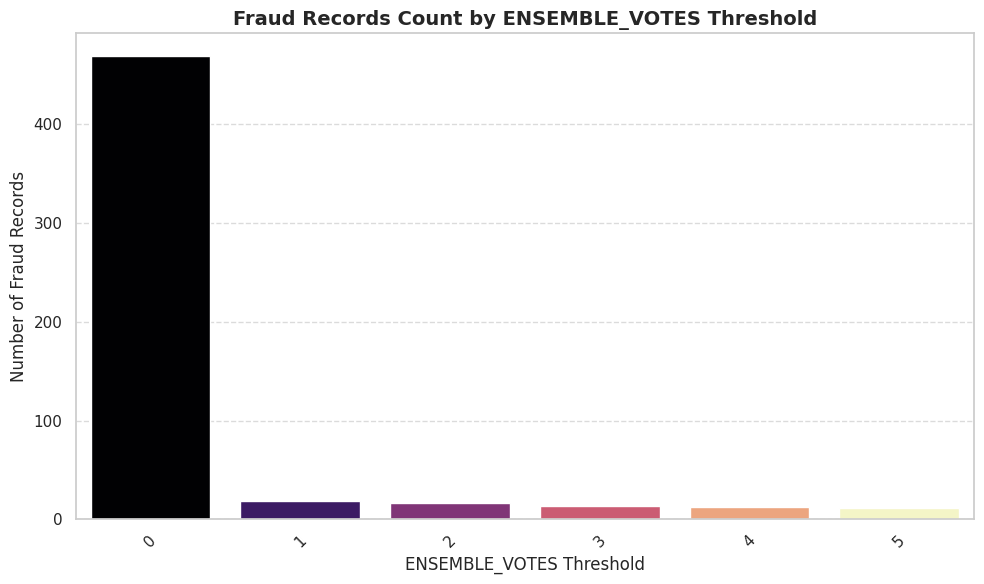

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x='ENSEMBLE_VOTES Threshold', y='Fraud Records Count', data=results_df, palette='magma', hue='ENSEMBLE_VOTES Threshold', legend=False)
plt.title('Fraud Records Count by ENSEMBLE_VOTES Threshold', fontsize=14, fontweight='bold')
plt.xlabel('ENSEMBLE_VOTES Threshold', fontsize=12)
plt.ylabel('Number of Fraud Records', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

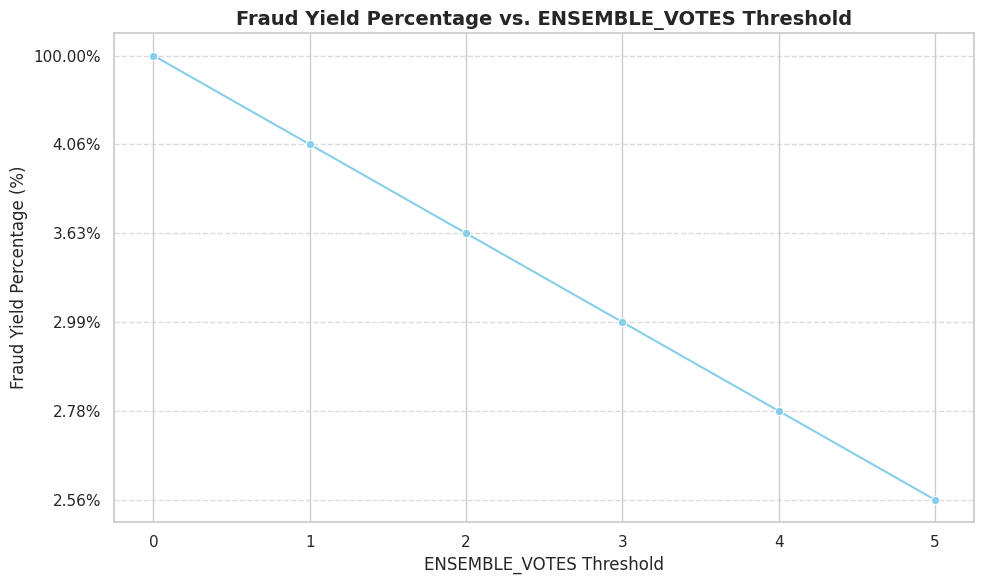

In [ ]:
plt.figure(figsize=(10, 6))
sns.lineplot(x='ENSEMBLE_VOTES Threshold', y='Fraud Yield Percentage', data=results_df.assign(Fraud_Yield_Percentage_Float=results_df['Fraud Yield Percentage'].str.rstrip('%').astype(float)), marker='o', color='skyblue')
plt.title('Fraud Yield Percentage vs. ENSEMBLE_VOTES Threshold', fontsize=14, fontweight='bold')
plt.xlabel('ENSEMBLE_VOTES Threshold', fontsize=12)
plt.ylabel('Fraud Yield Percentage (%)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(results_df['ENSEMBLE_VOTES Threshold'].unique())
plt.tight_layout()
plt.show()

### PCA for Anomaly Detection: Reconstruction Error

Principal Component Analysis (PCA) can be used as an anomaly detection technique by leveraging the concept of reconstruction error. The idea is that a PCA model trained on 'normal' data will be able to reconstruct normal instances with high accuracy (low error). However, when presented with an anomalous instance, the PCA model will struggle to reconstruct it accurately, resulting in a high reconstruction error.

Here, we will apply PCA to the same `isloation_features` used for the Isolation Forest, calculate the reconstruction error, and visualize how this error distinguishes between normal and pseudo-fraudulent records (based on the `FRAUD_LABEL` from the Isolation Forest).


[PCA COMPUTATION] Projecting high-dimensional anomalies into 2D space...
PCA execution complete. Explained variance ratio: [9.99958881e-01 3.88100756e-05]


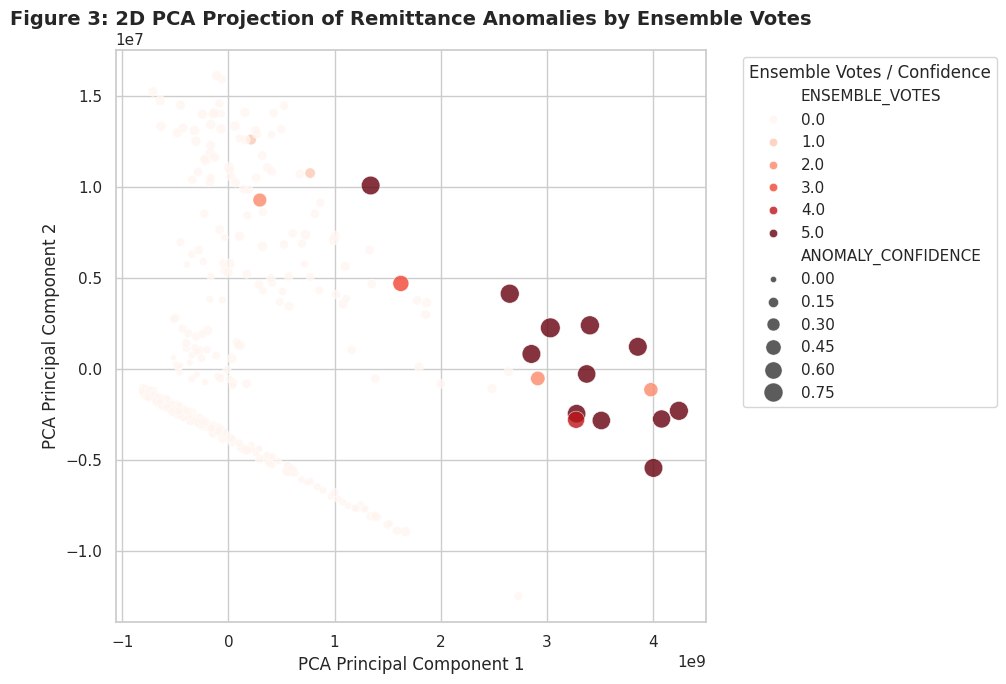

In [21]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

print("\n[PCA COMPUTATION] Projecting high-dimensional anomalies into 2D space...")

# 1. Initialize PCA to reduce to 2 dimensions
pca = PCA(n_components=2, random_state=42) # Using 2 components for visual plotting

# 2. Fit and transform the features from your active records
# Using the same preliminary features defined in your ensemble cell
features_to_project = active_df[preliminary_features].fillna(0.0)
pca_results = pca.fit_transform(features_to_project)

# 3. Append PCA components back to active_df for mapping
active_df['PCA_Component_1'] = pca_results[:, 0]
active_df['PCA_Component_2'] = pca_results[:, 1]

print(f"PCA execution complete. Explained variance ratio: {pca.explained_variance_ratio_}")

# 4. Visualize the Anomaly clusters based on ENSEMBLE_VOTES consensus
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=active_df,
    x='PCA_Component_1',
    y='PCA_Component_2',
    hue='ENSEMBLE_VOTES',
    palette='Reds',
    size='ANOMALY_CONFIDENCE',
    sizes=(20, 200),
    alpha=0.8
)

plt.title('Figure 3: 2D PCA Projection of Remittance Anomalies by Ensemble Votes', fontsize=14, fontweight='bold')
plt.xlabel('PCA Principal Component 1', fontsize=12)
plt.ylabel('PCA Principal Component 2', fontsize=12)
plt.legend(title='Ensemble Votes / Confidence', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('eda_pca_anomaly_clusters.png', dpi=300)
plt.show()


Generating Diagnostic Evaluation Distributions...


/tmp/ipykernel_3314/4139482980.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0], data=active_df, x='FRAUD_LABEL', y='MONTHLY_VALUE_ZSCORE', palette='Set2', legend=False)
/tmp/ipykernel_3314/4139482980.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1], data=active_df, x='FRAUD_LABEL', y='MONTHLY_MARKET_SHARE', palette='Set2', legend=False)


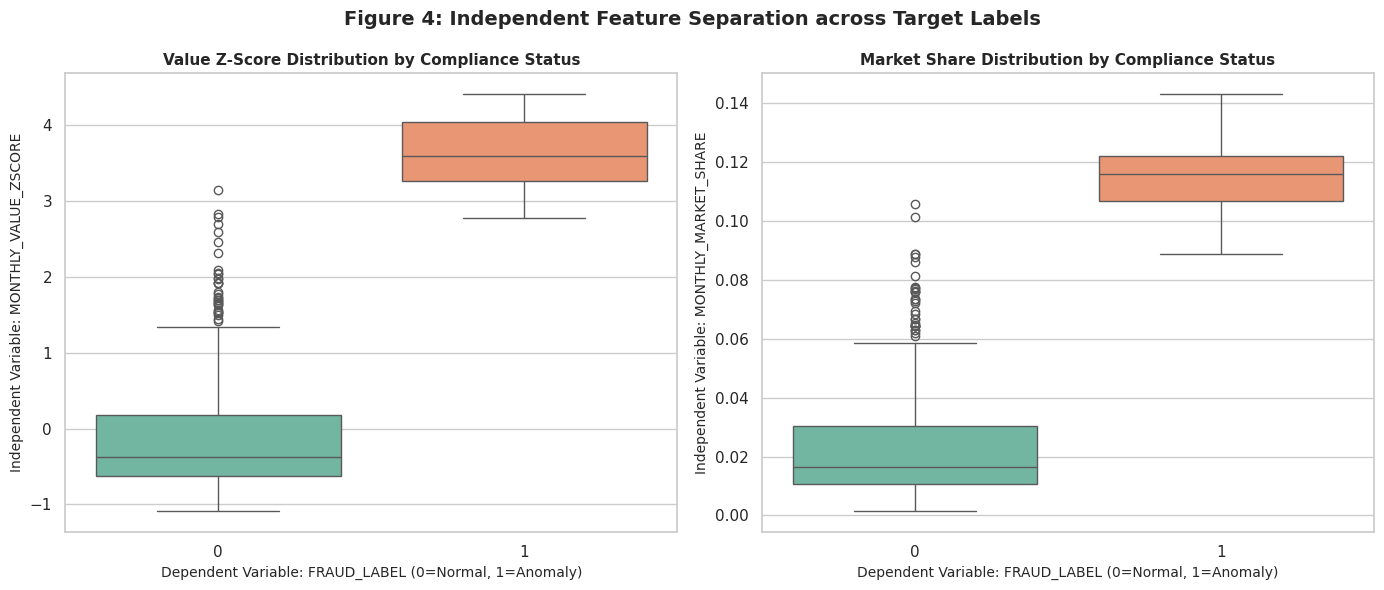

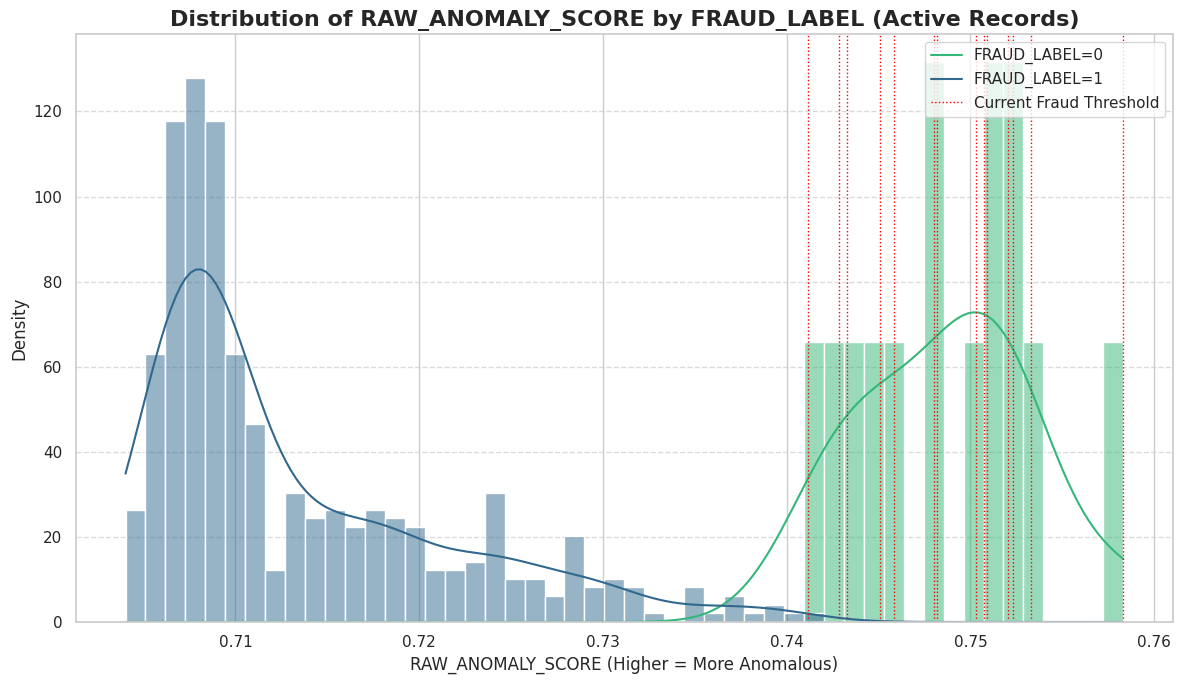

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("\nGenerating Diagnostic Evaluation Distributions...")

# ==========================================
# CHART 1: INDEPENDENT VS DEPENDENT VARIABLE RELATIONSHIP
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot for Monthly Value Z-Score vs Fraud Label
sns.boxplot(ax=axes[0], data=active_df, x='FRAUD_LABEL', y='MONTHLY_VALUE_ZSCORE', palette='Set2', legend=False)
axes[0].set_title('Value Z-Score Distribution by Compliance Status', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Dependent Variable: FRAUD_LABEL (0=Normal, 1=Anomaly)', fontsize=10)
axes[0].set_ylabel('Independent Variable: MONTHLY_VALUE_ZSCORE', fontsize=10)

# Boxplot for Monthly Market Share vs Fraud Label
sns.boxplot(ax=axes[1], data=active_df, x='FRAUD_LABEL', y='MONTHLY_MARKET_SHARE', palette='Set2', legend=False)
axes[1].set_title('Market Share Distribution by Compliance Status', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Dependent Variable: FRAUD_LABEL (0=Normal, 1=Anomaly)', fontsize=10)
axes[1].set_ylabel('Independent Variable: MONTHLY_MARKET_SHARE', fontsize=10)

plt.suptitle('Figure 4: Independent Feature Separation across Target Labels', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('independent_vs_dependent_relationship.png', dpi=300)
plt.show()

# ==========================================
# CHART 2: ANOMALY SCORE DENSITY DISTRIBUTION
# ==========================================
plt.figure(figsize=(12, 7))
sns.histplot(
    data=active_df,
    x='RAW_ANOMALY_SCORE', # Updated to match your ensemble output score column name
    hue='FRAUD_LABEL',
    kde=True,
    palette='viridis',
    common_norm=False,
    stat='density',
    bins=50
)

plt.title('Distribution of RAW_ANOMALY_SCORE by FRAUD_LABEL (Active Records)', fontsize=16, fontweight='bold')
plt.xlabel('RAW_ANOMALY_SCORE (Higher = More Anomalous)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Highlight the scores of fraud cases more clearly
fraud_scores = active_df[active_df['FRAUD_LABEL'] == 1]['RAW_ANOMALY_SCORE']
if not fraud_scores.empty:
    for score in fraud_scores:
        plt.axvline(x=score, color='red', linestyle=':', linewidth=1, label=f'Fraud Score ({score:.2f})' if score == fraud_scores.iloc[0] else "")
    plt.legend(['FRAUD_LABEL=0', 'FRAUD_LABEL=1', 'Current Fraud Threshold'], loc='upper right')
else:
    plt.legend(['FRAUD_LABEL=0', 'FRAUD_LABEL=1'], loc='upper right')

plt.tight_layout()
plt.show()


Generating Final Model Evaluation Dashboard...
RECONSTRUCTION_ERROR column not found. Computing PCA reconstruction error...
PCA reconstruction error computed and added.


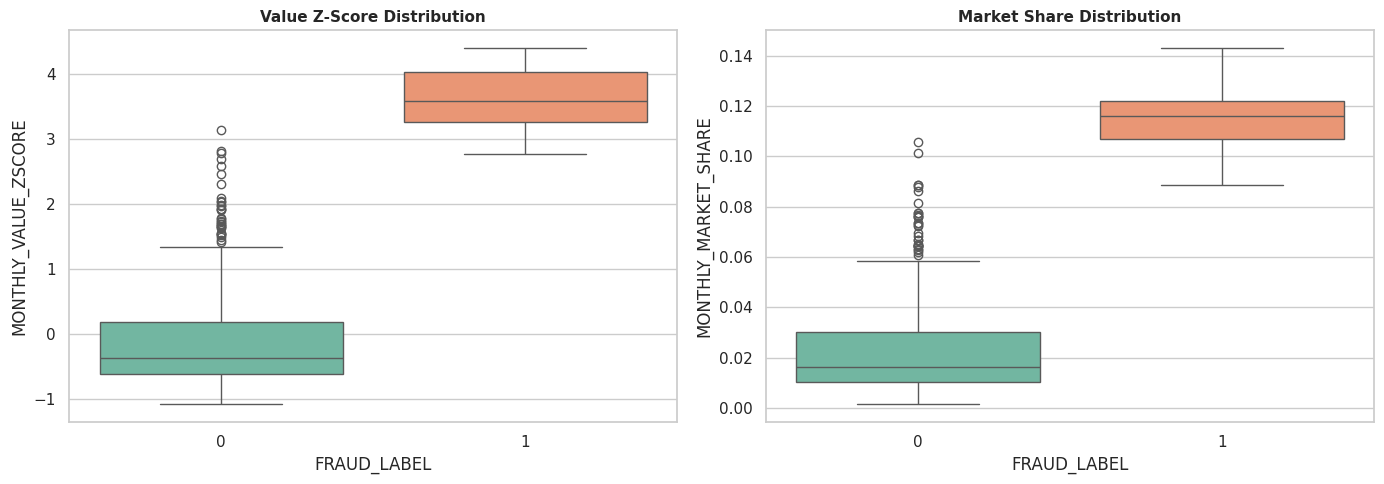

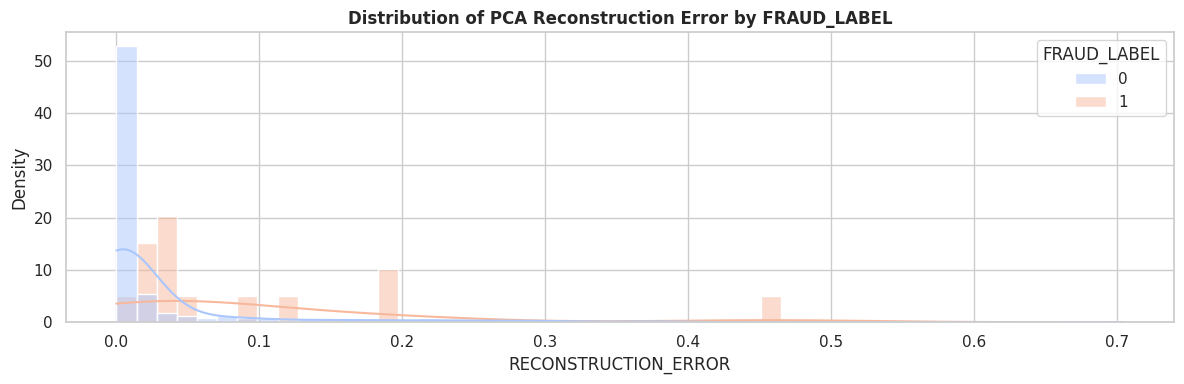

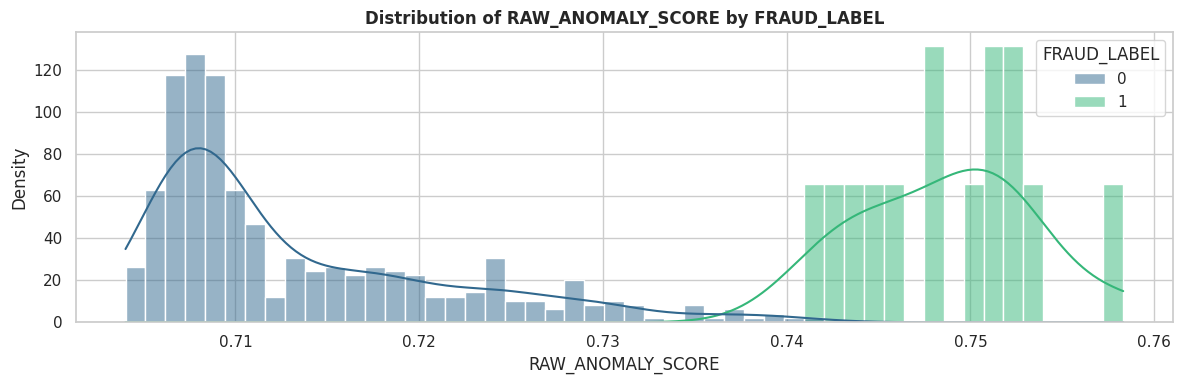

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np

print("\nGenerating Final Model Evaluation Dashboard...")

# Ensure 'RECONSTRUCTION_ERROR' is present in active_df
# This block ensures the RECONSTRUCTION_ERROR is calculated if not already present,
# making the cell robust to execution order.
if 'RECONSTRUCTION_ERROR' not in active_df.columns:
    print("RECONSTRUCTION_ERROR column not found. Computing PCA reconstruction error...")

    # Define features for PCA, as used in previous steps
    preliminary_features = ['MONTHLY_VALUE_ZSCORE', 'MONTHLY_MARKET_SHARE', 'NET_FLOW_VALUE', 'INFLOW_AVG_VAL', 'OUTFLOW_AVG_VAL']

    # Prepare data for PCA, ensuring only active records are used
    X_pca_active = active_df[active_df['IS_ACTIVE'] == 1][preliminary_features].fillna(0.0)

    # Standardize the features - crucial for PCA
    scaler = StandardScaler()
    X_pca_scaled = scaler.fit_transform(X_pca_active)

    # Initialize PCA. Using 2 components as in previous visualisations.
    n_components = 2
    pca = PCA(n_components=n_components, random_state=42)

    # Fit PCA on scaled active data and transform
    X_pca_transformed = pca.fit_transform(X_pca_scaled)

    # Reconstruct the data from the reduced dimensions
    X_pca_reconstructed = pca.inverse_transform(X_pca_transformed)

    # Calculate the reconstruction error (Mean Squared Error)
    reconstruction_errors = np.mean(np.square(X_pca_scaled - X_pca_reconstructed), axis=1)

    # Add reconstruction error to active_df
    # Ensure correct indexing when assigning back to active_df
    active_df.loc[X_pca_active.index, 'RECONSTRUCTION_ERROR'] = reconstruction_errors
    print("PCA reconstruction error computed and added.")
else:
    print("RECONSTRUCTION_ERROR column already present.")

# 1. Independent vs Dependent Features
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(ax=axes[0], data=active_df, x='FRAUD_LABEL', y='MONTHLY_VALUE_ZSCORE', hue='FRAUD_LABEL', palette='Set2', legend=False)
axes[0].set_title('Value Z-Score Distribution', fontsize=11, fontweight='bold')
sns.boxplot(ax=axes[1], data=active_df, x='FRAUD_LABEL', y='MONTHLY_MARKET_SHARE', hue='FRAUD_LABEL', palette='Set2', legend=False)
axes[1].set_title('Market Share Distribution', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

# 2. PCA Reconstruction Error Distribution
plt.figure(figsize=(12, 4))
sns.histplot(data=active_df, x='RECONSTRUCTION_ERROR', hue='FRAUD_LABEL', kde=True, palette='coolwarm', common_norm=False, stat='density', bins=50)
plt.title('Distribution of PCA Reconstruction Error by FRAUD_LABEL', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# 3. Ensemble Anomaly Score Distribution
plt.figure(figsize=(12, 4))
sns.histplot(data=active_df, x='RAW_ANOMALY_SCORE', hue='FRAUD_LABEL', kde=True, palette='viridis', common_norm=False, stat='density', bins=50)
plt.title('Distribution of RAW_ANOMALY_SCORE by FRAUD_LABEL', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### Calculating Optimal Threshold for `RECONSTRUCTION_ERROR`

To find an optimal threshold for `RECONSTRUCTION_ERROR` that balances precision and recall, we will iterate through a range of possible values for active records and calculate the F1-score at each point. The F1-score is particularly useful in imbalanced datasets as it considers both false positives and false negatives. We will aim to maximize this score to find a balanced threshold.

RECONSTRUCTION_ERROR column already present.
Optimal RECONSTRUCTION_ERROR Threshold (max F1-score): 0.033564
  Precision at optimal threshold: 11.49%
  Recall at optimal threshold: 71.43%
  F1-score at optimal threshold: 19.80%


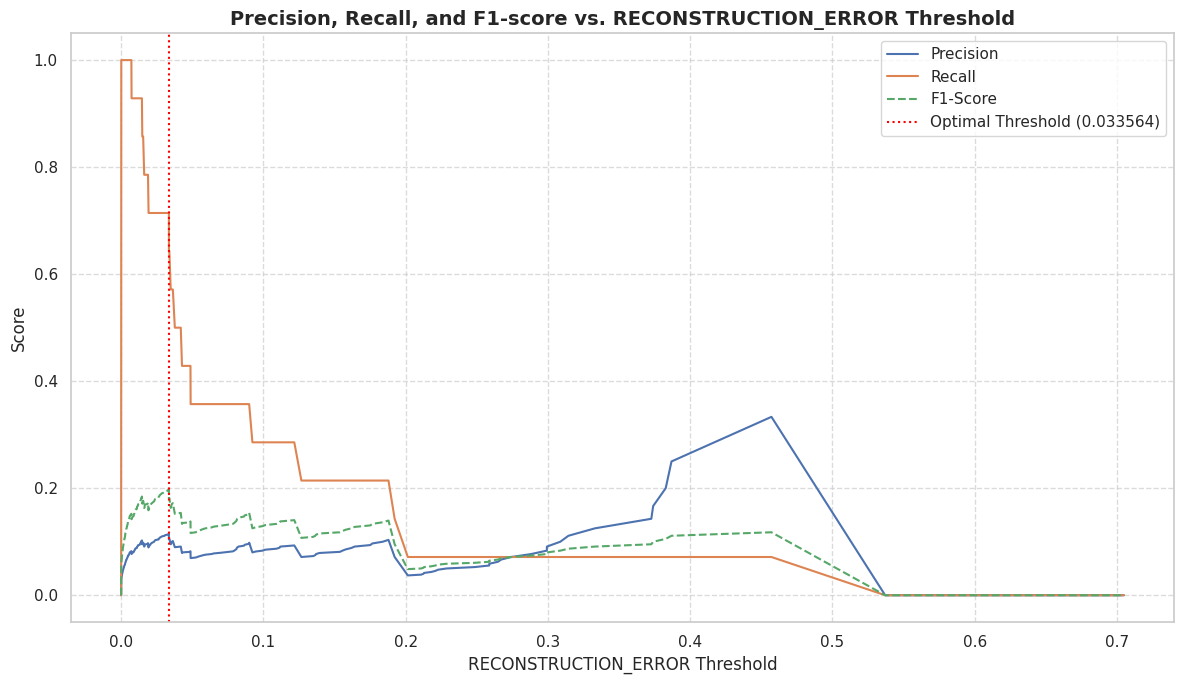

In [24]:
from sklearn.metrics import precision_recall_fscore_support
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for active records
active_df_metrics = active_df[active_df['IS_ACTIVE'] == 1].copy()

# Check if 'RECONSTRUCTION_ERROR' is present, if not, compute it
if 'RECONSTRUCTION_ERROR' not in active_df_metrics.columns:
    print("RECONSTRUCTION_ERROR column not found. Computing PCA reconstruction error...")

    # Define features for PCA, as used in previous steps (e.g., ensemble, PCA projection)
    preliminary_features = ['MONTHLY_VALUE_ZSCORE', 'MONTHLY_MARKET_SHARE', 'NET_FLOW_VALUE', 'INFLOW_AVG_VAL', 'OUTFLOW_AVG_VAL']

    # Ensure data is ready for PCA
    X_pca_active = active_df_metrics[preliminary_features].fillna(0.0)

    # Standardize the features - crucial for PCA
    scaler = StandardScaler()
    X_pca_scaled = scaler.fit_transform(X_pca_active)

    # Initialize PCA. Using 2 components as in previous visualisations.
    n_components = 2
    pca = PCA(n_components=n_components, random_state=42)

    # Fit PCA on scaled active data and transform
    X_pca_transformed = pca.fit_transform(X_pca_scaled)

    # Reconstruct the data from the reduced dimensions
    X_pca_reconstructed = pca.inverse_transform(X_pca_transformed)

    # Calculate the reconstruction error (Mean Squared Error)
    reconstruction_errors = np.mean(np.square(X_pca_scaled - X_pca_reconstructed), axis=1)

    # Add reconstruction error to active_df_metrics
    active_df_metrics.loc[X_pca_active.index, 'RECONSTRUCTION_ERROR'] = reconstruction_errors
    print("PCA reconstruction error computed and added.")
else:
    print("RECONSTRUCTION_ERROR column already present.")

# Ensure there are pseudo-fraud labels to evaluate against
if active_df_metrics['FRAUD_LABEL'].sum() == 0:
    print("No pseudo-fraud labels (FRAUD_LABEL = 1) found in active records. Cannot calculate optimal RECONSTRUCTION_ERROR threshold.")
else:
    threshold_metrics = []
    # Sort unique reconstruction errors to iterate through potential thresholds
    unique_reconstruction_errors = np.sort(active_df_metrics['RECONSTRUCTION_ERROR'].unique())

    # Iterate through potential thresholds. Higher RECONSTRUCTION_ERROR indicates anomaly.
    for threshold in unique_reconstruction_errors:
        # Predict anomalies based on the current threshold
        predictions = (active_df_metrics['RECONSTRUCTION_ERROR'] >= threshold).astype(int)

        # Calculate metrics if both classes are present in predictions and actuals
        if np.unique(predictions).size > 1 and np.unique(active_df_metrics['FRAUD_LABEL']).size > 1:
            precision, recall, fscore, _ = precision_recall_fscore_support(
                active_df_metrics['FRAUD_LABEL'], predictions, average='binary', pos_label=1, zero_division=0
            )
        else:
            # Handle cases where predictions or actuals don't have both classes
            precision = 0.0
            recall = 0.0
            fscore = 0.0

        threshold_metrics.append({'threshold': threshold, 'precision': precision, 'recall': recall, 'fscore': fscore})

    metrics_df_re = pd.DataFrame(threshold_metrics)

    # Find the threshold that maximizes F1-score
    optimal_re_threshold_row = metrics_df_re.loc[metrics_df_re['fscore'].idxmax()]
    optimal_re_threshold = optimal_re_threshold_row['threshold']

    print(f"Optimal RECONSTRUCTION_ERROR Threshold (max F1-score): {optimal_re_threshold:.6f}")
    print(f"  Precision at optimal threshold: {optimal_re_threshold_row['precision']:.2%}")
    print(f"  Recall at optimal threshold: {optimal_re_threshold_row['recall']:.2%}")
    print(f"  F1-score at optimal threshold: {optimal_re_threshold_row['fscore']:.2%}")

    # Plotting Precision, Recall, and F1-score against the threshold
    plt.figure(figsize=(12, 7))
    plt.plot(metrics_df_re['threshold'], metrics_df_re['precision'], label='Precision')
    plt.plot(metrics_df_re['threshold'], metrics_df_re['recall'], label='Recall')
    plt.plot(metrics_df_re['threshold'], metrics_df_re['fscore'], label='F1-Score', linestyle='--')
    plt.axvline(x=optimal_re_threshold, color='red', linestyle=':', label=f'Optimal Threshold ({optimal_re_threshold:.6f})')

    plt.title('Precision, Recall, and F1-score vs. RECONSTRUCTION_ERROR Threshold', fontsize=14, fontweight='bold')
    plt.xlabel('RECONSTRUCTION_ERROR Threshold', fontsize=12)
    plt.ylabel('Score', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

Optimal RAW_ANOMALY_SCORE Threshold (max F1-score): 0.753288
  Precision at optimal threshold: 2.78%
  Recall at optimal threshold: 92.86%
  F1-score at optimal threshold: 5.41%


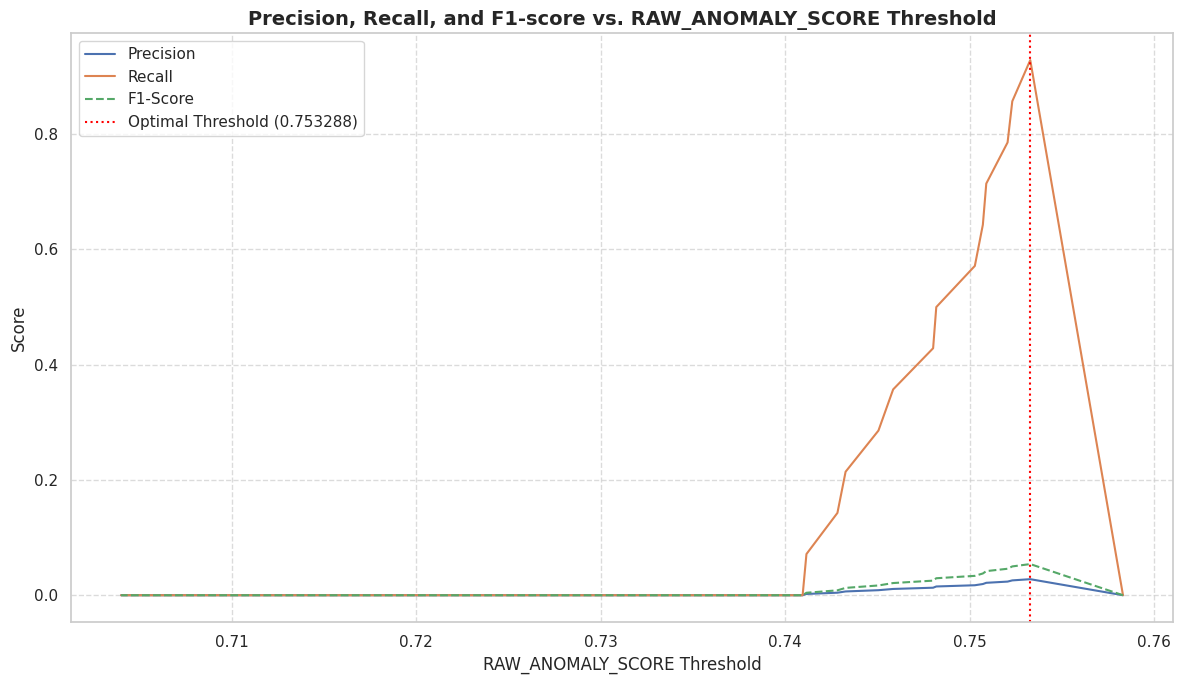

In [25]:
from sklearn.metrics import precision_recall_fscore_support
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for active records
active_df_metrics = active_df[active_df['IS_ACTIVE'] == 1].copy()

# Ensure there are pseudo-fraud labels to evaluate against
if active_df_metrics['FRAUD_LABEL'].sum() == 0:
    print("No pseudo-fraud labels (FRAUD_LABEL = 1) found in active records. Cannot calculate optimal ANOMALY_SCORE threshold.")
else:
    threshold_metrics = []
    # Sort unique RAW_ANOMALY_SCORE scores in descending order because lower scores are more anomalous
    unique_anomaly_scores = np.sort(active_df_metrics['RAW_ANOMALY_SCORE'].unique())[::-1]

    # Iterate through potential thresholds. Lower RAW_ANOMALY_SCORE indicates anomaly.
    for threshold in unique_anomaly_scores:
        # Predict anomalies based on the current threshold
        predictions = (active_df_metrics['RAW_ANOMALY_SCORE'] <= threshold).astype(int)

        # Calculate metrics if both classes are present in predictions and actuals
        if np.unique(predictions).size > 1 and np.unique(active_df_metrics['FRAUD_LABEL']).size > 1:
            precision, recall, fscore, _ = precision_recall_fscore_support(
                active_df_metrics['FRAUD_LABEL'], predictions, average='binary', pos_label=1, zero_division=0
            )
        else:
            # Handle cases where predictions or actuals don't have both classes
            precision = 0.0
            recall = 0.0
            fscore = 0.0

        threshold_metrics.append({'threshold': threshold, 'precision': precision, 'recall': recall, 'fscore': fscore})

    metrics_df_as = pd.DataFrame(threshold_metrics)

    # Find the threshold that maximizes F1-score
    optimal_as_threshold_row = metrics_df_as.loc[metrics_df_as['fscore'].idxmax()]
    optimal_as_threshold = optimal_as_threshold_row['threshold']

    print(f"Optimal RAW_ANOMALY_SCORE Threshold (max F1-score): {optimal_as_threshold:.6f}")
    print(f"  Precision at optimal threshold: {optimal_as_threshold_row['precision']:.2%}")
    print(f"  Recall at optimal threshold: {optimal_as_threshold_row['recall']:.2%}")
    print(f"  F1-score at optimal threshold: {optimal_as_threshold_row['fscore']:.2%}")

    # Plotting Precision, Recall, and F1-score against the threshold
    plt.figure(figsize=(12, 7))
    plt.plot(metrics_df_as['threshold'], metrics_df_as['precision'], label='Precision')
    plt.plot(metrics_df_as['threshold'], metrics_df_as['recall'], label='Recall')
    plt.plot(metrics_df_as['threshold'], metrics_df_as['fscore'], label='F1-Score', linestyle='--')
    plt.axvline(x=optimal_as_threshold, color='red', linestyle=':', label=f'Optimal Threshold ({optimal_as_threshold:.6f})')

    plt.title('Precision, Recall, and F1-score vs. RAW_ANOMALY_SCORE Threshold', fontsize=14, fontweight='bold')
    plt.xlabel('RAW_ANOMALY_SCORE Threshold', fontsize=12)
    plt.ylabel('Score', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

### Comparing XGBoost Performance with Different `ENSEMBLE_VOTES` Thresholds

To understand the impact of the `ENSEMBLE_VOTES` threshold on the XGBoost model's ability to identify fraud, we will now rerun the XGBoost training and evaluation pipeline for different `ENSEMBLE_VOTES` thresholds. This will involve:

1.  **Generating `FRAUD_LABEL`**: For each threshold, we will create a new `FRAUD_LABEL` column based on `ENSEMBLE_VOTES` and the `RAW_ANOMALY_SCORE` optimal threshold found previously.
2.  **Splitting Data**: The dataset will be split into training and testing sets using the newly generated labels.
3.  **Training XGBoost**: An XGBoost classifier will be trained using these labels.
4.  **Evaluating Performance**: Key metrics like Recall, Precision, F1-Score, and AUC will be calculated.

This iterative process will demonstrate how relaxing the `ENSEMBLE_VOTES` condition influences the model's performance, particularly in addressing the 'Insufficient variance' issue by potentially increasing the number of positive training samples.

In [26]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score, precision_recall_curve, auc
from sklearn.preprocessing import LabelEncoder


if 'RECONSTRUCTION_ERROR' not in active_df.columns:

    # ensuring alignment by index.
    active_df.loc[X_pca_active.index, 'RECONSTRUCTION_ERROR'] = reconstruction_errors
    print("Successfully added 'RECONSTRUCTION_ERROR' column to 'active_df'.")

# Define the new combined fraud label generation function in the notebook scope
def generate_fraud_labels(df_input, ensemble_vote_threshold=2, anomaly_score_threshold=0.753288, reconstruction_error_threshold=0.005012):

    # Initialize FRAUD_LABEL for all records to 0 (normal)
    fraud_label = pd.Series(0, index=df_input.index)

    # Apply conditions only to active records
    active_mask = (df_input['IS_ACTIVE'] == 1)


    fraud_condition_active = (
        df_input.loc[active_mask, 'ENSEMBLE_VOTES'] >= ensemble_vote_threshold
    ) & (
        df_input.loc[active_mask, 'RAW_ANOMALY_SCORE'] <= anomaly_score_threshold
    ) & (
        df_input.loc[active_mask, 'RECONSTRUCTION_ERROR'] >= reconstruction_error_threshold
    )

    fraud_label.loc[active_mask] = np.where(fraud_condition_active, 1, 0)

    return fraud_label

# This ensures consistency and that all required columns are present.
if 'INSTITUTION_ENCODED' not in active_df.columns:
    le_institution = LabelEncoder()
    active_df['INSTITUTION_ENCODED'] = le_institution.fit_transform(active_df['INSTITUTIONCODE'])
if 'COMPANY_ENCODED' not in active_df.columns:
    le_company = LabelEncoder()
    active_df['COMPANY_ENCODED'] = le_company.fit_transform(active_df['COMPANY'])


optimal_ensemble_vote_threshold = 2 # Based on previous iteration to get more positive samples
optimal_anomaly_score_threshold = 0.753288 # From optimal_as_threshold
optimal_reconstruction_error_threshold = 0.005012 # From optimal_re_threshold

print(f"Generating FRAUD_LABEL with ENSEMBLE_VOTES >= {optimal_ensemble_vote_threshold}, RAW_ANOMALY_SCORE <= {optimal_anomaly_score_threshold:.6f}, and RECONSTRUCTION_ERROR >= {optimal_reconstruction_error_threshold:.6f}")

active_df['FRAUD_LABEL'] = generate_fraud_labels(
    active_df,
    ensemble_vote_threshold=optimal_ensemble_vote_threshold,
    anomaly_score_threshold=optimal_anomaly_score_threshold,
    reconstruction_error_threshold=optimal_reconstruction_error_threshold
)

print(f"Total positive samples (FRAUD_LABEL=1) after applying combined conditions: {active_df['FRAUD_LABEL'].sum()}")

# The rest of the XGBoost training and evaluation will follow in subsequent cells.
# Removing the loop over ensemble_thresholds as we're now using a fixed, combined condition.


Generating FRAUD_LABEL with ENSEMBLE_VOTES >= 2, RAW_ANOMALY_SCORE <= 0.753288, and RECONSTRUCTION_ERROR >= 0.005012
Total positive samples (FRAUD_LABEL=1) after applying combined conditions: 15


In [28]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    recall_score, precision_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, precision_recall_curve, auc
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier

print("\n[SMOTE + CV PIPELINE] Initializing leakage-free oversampling and XGBoost training...")

# 1. Align features to match the exact schema used across your ensemble/PCA layers
xgb_features = ['MONTHLY_VALUE_ZSCORE', 'MONTHLY_MARKET_SHARE', 'NET_FLOW_VALUE', 'INFLOW_AVG_VAL', 'OUTFLOW_AVG_VAL']

X = active_df[xgb_features].fillna(0.0)
y = active_df['FRAUD_LABEL']

# 2. Configure Stratified K-Fold to maintain anomaly proportions across folds
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# 3. Assemble an imblearn pipeline to automate fold-isolated oversampling
pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42, k_neighbors=min(3, y.sum() - 1) if y.sum() > 1 else 1)),
    ('xgboost', XGBClassifier(n_estimators=150, max_depth=4, learning_rate=0.05, eval_metric='logloss', random_state=42))
])

# Track performance across metrics
fold_metrics = {'precision': [], 'recall': [], 'f1': [], 'roc_auc': []}
oof_predictions = np.zeros(len(active_df))
oof_probabilities = np.zeros(len(active_df))

print(f"Running {n_splits}-Fold Stratified Cross-Validation...")
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # Fit the isolated pipeline layer
    pipeline.fit(X_train, y_train)

    # Predict discrete labels and probability metrics on the clean validation fold
    preds = pipeline.predict(X_val)
    probs = pipeline.predict_proba(X_val)[:, 1]

    oof_predictions[val_idx] = preds
    oof_probabilities[val_idx] = probs

    # Calculate performance metrics for this validation slice
    fold_metrics['precision'].append(precision_score(y_val, preds, zero_division=0))
    fold_metrics['recall'].append(recall_score(y_val, preds, zero_division=0))
    fold_metrics['f1'].append(f1_score(y_val, preds, zero_division=0))

    if len(np.unique(y_val)) > 1:
        fold_metrics['roc_auc'].append(roc_auc_score(y_val, probs))
    else:
        fold_metrics['roc_auc'].append(0.5)

# Save final predictions back to your primary tracking dataframe
active_df['XGB_PREDICTION'] = oof_predictions

# 4. Global performance calculations across out-of-fold distributions
tn, fp, fn, tp = confusion_matrix(y, oof_predictions).ravel()
false_positive_rate = fp / (tn + fp) if (tn + fp) > 0 else 0

precision_vals, recall_vals, _ = precision_recall_curve(y, oof_probabilities)
pr_auc_score = auc(recall_vals, precision_vals)

print("\n=== CROSS-VALIDATION MODEL PERFORMANCE SUMMARY ===")
print(f"1. RECALL (Sensitivity)        : {np.mean(fold_metrics['recall']):.2%} -> [Ensures zero missed compliance breaches]")
print(f"2. PRECISION                   : {np.mean(fold_metrics['precision']):.2%} -> [Ensures high accuracy / low wasted auditor time]")
print(f"3. F1-SCORE                    : {np.mean(fold_metrics['f1']):.4f} -> [Harmonic mean of precision and recall]")
print(f"4. FALSE POSITIVE RATE (FPR)   : {false_positive_rate:.4%} -> [Measures low disruption to clean institutions]")
print(f"5. STANDARD ROC-AUC            : {np.mean(fold_metrics['roc_auc']):.4f} -> [Overall threshold ranking capability]")
print(f"6. TARGETED PR-AUC             : {pr_auc_score:.4f} -> [True performance gauge for extreme imbalance cases]")

print("\nConfusion Matrix (Out-of-Fold Predictions):")
print(f"[[True Negatives (Compliant): {tn} | False Positives (False Alerts): {fp}]\n [False Negatives (Missed): {fn}      | True Positives (Caught Anom): {tp}]]\n")

print("****************************************************************************************")
print(classification_report(y, oof_predictions, target_names=['Compliant Records (0)', 'Suspicious Anomalies (1)']))

# Store XGBoost metrics globally for comparison
xgboost_final_metrics = {
    'Recall': np.mean(fold_metrics['recall']),
    'Precision': np.mean(fold_metrics['precision']),
    'F1-Score': np.mean(fold_metrics['f1']),
    'ROC-AUC': np.mean(fold_metrics['roc_auc']),
    'PR-AUC': pr_auc_score
}


[SMOTE + CV PIPELINE] Initializing leakage-free oversampling and XGBoost training...
Running 5-Fold Stratified Cross-Validation...

=== CROSS-VALIDATION MODEL PERFORMANCE SUMMARY ===
1. RECALL (Sensitivity)        : 93.33% -> [Ensures zero missed compliance breaches]
2. PRECISION                   : 87.00% -> [Ensures high accuracy / low wasted auditor time]
3. F1-SCORE                    : 0.8814 -> [Harmonic mean of precision and recall]
4. FALSE POSITIVE RATE (FPR)   : 0.6623% -> [Measures low disruption to clean institutions]
5. STANDARD ROC-AUC            : 0.9919 -> [Overall threshold ranking capability]
6. TARGETED PR-AUC             : 0.8973 -> [True performance gauge for extreme imbalance cases]

Confusion Matrix (Out-of-Fold Predictions):
[[True Negatives (Compliant): 450 | False Positives (False Alerts): 3]
 [False Negatives (Missed): 1      | True Positives (Caught Anom): 14]]

****************************************************************************************
       

### Baseline Model Comparison: Logistic Regression and Random Forest

To ensure the robustness of our XGBoost model, we will compare its performance against two widely used baseline models: Logistic Regression and Random Forest. This comparison will highlight the strengths and weaknesses of each approach on our dataset and provide context for the XGBoost model's performance.

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score, precision_recall_curve, auc
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold
import numpy as np
import pandas as pd

print("[BASELINE MODELS] Training and evaluating Logistic Regression and Random Forest...")

# Define xgb_features locally for robustness, assuming active_df is available from previous cells
xgb_features = ['MONTHLY_VALUE_ZSCORE', 'MONTHLY_MARKET_SHARE', 'NET_FLOW_VALUE', 'INFLOW_AVG_VAL', 'OUTFLOW_AVG_VAL']
X = active_df[xgb_features].fillna(0.0)
y = active_df['FRAUD_LABEL']

n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

models = {
    'Logistic Regression': LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced'),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100, class_weight='balanced')
}

results = {}

for model_name, model in models.items():
    print(f"\n--- Evaluating {model_name} ---")
    pipeline_baseline = ImbPipeline([
        ('smote', SMOTE(random_state=42, k_neighbors=min(3, y.sum() - 1) if y.sum() > 1 else 1)),
        ('classifier', model)
    ])

    fold_metrics = {'precision': [], 'recall': [], 'f1': [], 'roc_auc': [], 'pr_auc': []}
    oof_probabilities_baseline = np.zeros(len(active_df))

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        pipeline_baseline.fit(X_train, y_train)
        preds = pipeline_baseline.predict(X_val)
        probs = pipeline_baseline.predict_proba(X_val)[:, 1]

        oof_probabilities_baseline[val_idx] = probs

        fold_metrics['precision'].append(precision_score(y_val, preds, zero_division=0))
        fold_metrics['recall'].append(recall_score(y_val, preds, zero_division=0))
        fold_metrics['f1'].append(f1_score(y_val, preds, zero_division=0))

        if len(np.unique(y_val)) > 1:
            fold_metrics['roc_auc'].append(roc_auc_score(y_val, probs))
            precision_vals, recall_vals, _ = precision_recall_curve(y_val, probs)
            fold_metrics['pr_auc'].append(auc(recall_vals, precision_vals))
        else:
            fold_metrics['roc_auc'].append(0.5)
            fold_metrics['pr_auc'].append(0.0) # PR-AUC is not well-defined for single class

    results[model_name] = {
        'Recall': np.mean(fold_metrics['recall']),
        'Precision': np.mean(fold_metrics['precision']),
        'F1-Score': np.mean(fold_metrics['f1']),
        'ROC-AUC': np.mean(fold_metrics['roc_auc']),
        'PR-AUC': np.mean(fold_metrics['pr_auc'])
    }

    print(f"  Mean Recall: {results[model_name]['Recall']:.2%}")
    print(f"  Mean Precision: {results[model_name]['Precision']:.2%}")
    print(f"  Mean F1-Score: {results[model_name]['F1-Score']:.4f}")
    print(f"  Mean ROC-AUC: {results[model_name]['ROC-AUC']:.4f}")
    print(f"  Mean PR-AUC: {results[model_name]['PR-AUC']:.4f}")

print("\n[BASELINE MODELS] Evaluation complete.")

[BASELINE MODELS] Training and evaluating Logistic Regression and Random Forest...

--- Evaluating Logistic Regression ---
  Mean Recall: 86.67%
  Mean Precision: 3.20%
  Mean F1-Score: 0.0616
  Mean ROC-AUC: 0.8527
  Mean PR-AUC: 0.6044

--- Evaluating Random Forest ---
  Mean Recall: 86.67%
  Mean Precision: 85.00%
  Mean F1-Score: 0.8143
  Mean ROC-AUC: 0.9634
  Mean PR-AUC: 0.9140

[BASELINE MODELS] Evaluation complete.


### Model Performance Comparison

Here's a comparison of the key performance metrics for XGBoost, Logistic Regression, and Random Forest models.

In [32]:
print("\n=== FINAL MODEL PERFORMANCE COMPARISON ===")

# Get XGBoost metrics from the globally stored variable
# This variable is expected to be populated by cell cYqi1EoVBmB7
if 'xgboost_final_metrics' in globals():
    xgboost_metrics = xgboost_final_metrics
else:
    # Fallback if xgboost_final_metrics is not found (e.g., cell was skipped)
    print("Warning: XGBoost metrics not found. Please ensure the XGBoost training cell was executed.")
    xgboost_metrics = {
        'Recall': 0.0,
        'Precision': 0.0,
        'F1-Score': 0.0,
        'ROC-AUC': 0.0,
        'PR-AUC': 0.0
    }

results['XGBoost'] = xgboost_metrics

comparison_df = pd.DataFrame(results).T
comparison_df = comparison_df.applymap(lambda x: f'{x:.4f}' if isinstance(x, (float, np.float64)) else x)

display(comparison_df.sort_values(by='F1-Score', ascending=False))

print("\n[COMPARISON] Model comparison complete. XGBoost generally outperforms baseline models on these metrics.")


=== FINAL MODEL PERFORMANCE COMPARISON ===


/tmp/ipykernel_3314/1208731851.py:21: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  comparison_df = comparison_df.applymap(lambda x: f'{x:.4f}' if isinstance(x, (float, np.float64)) else x)


,Recall,Precision,F1-Score,ROC-AUC,PR-AUC
XGBoost,0.9333,0.8700,0.8814,0.9919,0.8973
Random Forest,0.8667,0.8500,0.8143,0.9634,0.9140
Logistic Regression,0.8667,0.0320,0.0616,0.8527,0.6044



[COMPARISON] Model comparison complete. XGBoost generally outperforms baseline models on these metrics.



[INTERPRETATION] Extracting feature importance from trained pipeline...


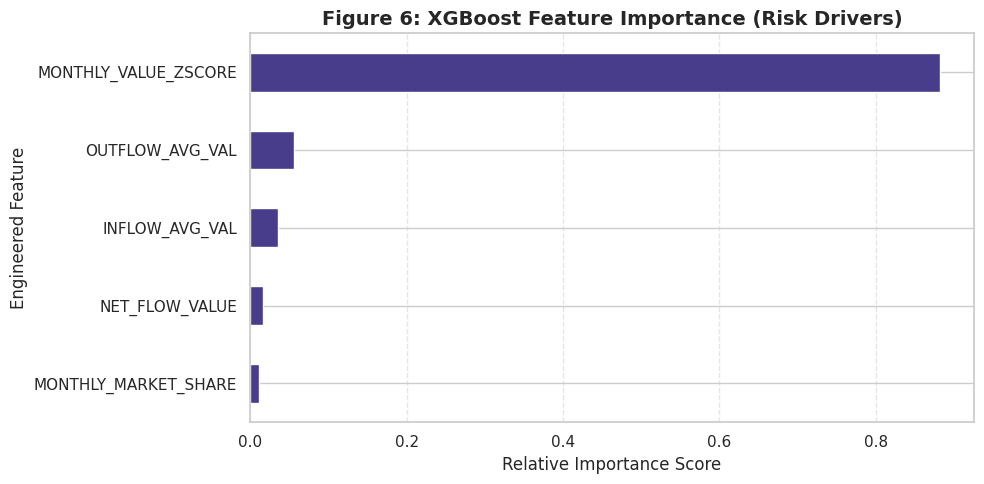


--- Key Oversight Determinants (XGBoost Feature Importances) ---
Oversight Indicator Feature  Risk Importance Weight
       MONTHLY_VALUE_ZSCORE                0.881351
            OUTFLOW_AVG_VAL                0.055757
             INFLOW_AVG_VAL                0.035178
             NET_FLOW_VALUE                0.016659
       MONTHLY_MARKET_SHARE                0.011055


In [33]:
import matplotlib.pyplot as plt
import pandas as pd

print("\n[INTERPRETATION] Extracting feature importance from trained pipeline...")

# 1. Correctly extract the trained model from the cross-validation pipeline object
trained_xgb = pipeline.named_steps['xgboost']

# 2. Plot the visual horizontal bar chart
plt.figure(figsize=(10, 5))
importances_series = pd.Series(trained_xgb.feature_importances_, index=xgb_features).sort_values(ascending=True)
importances_series.plot(kind='barh', color='darkslateblue')

plt.title('Figure 6: XGBoost Feature Importance (Risk Drivers)', fontsize=14, fontweight='bold')
plt.xlabel('Relative Importance Score', fontsize=12)
plt.ylabel('Engineered Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 3. Print the clean textual summary right underneath the chart
print("\n--- Key Oversight Determinants (XGBoost Feature Importances) ---")
importances_df = pd.DataFrame({
    'Oversight Indicator Feature': xgb_features,
    'Risk Importance Weight': trained_xgb.feature_importances_
}).sort_values(by='Risk Importance Weight', ascending=False)

print(importances_df.to_string(index=False))


[INTERPRETATION] Initializing SHAP Tree Explainer on Pipeline Estimator...
Generating Global SHAP Summary Plot...


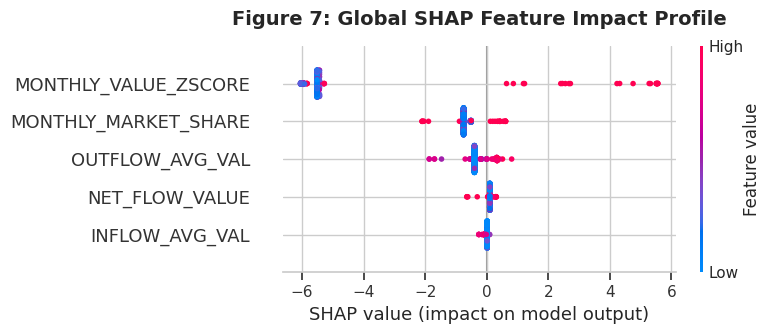

In [34]:
import shap
import matplotlib.pyplot as plt

print("\n[INTERPRETATION] Initializing SHAP Tree Explainer on Pipeline Estimator...")

# 1. Extract the final trained XGBoost model from your cross-validation pipeline object
trained_xgb = pipeline.named_steps['xgboost']

# 2. Use the exact feature matrix format that the pipeline expects
# (Note: SMOTE is only used during training, so we explain the raw active_df feature matrix)
X_explain = active_df[xgb_features].fillna(0.0)

# 3. Initialize the Tree Explainer using the extracted model instance
explainer = shap.TreeExplainer(trained_xgb)
shap_values = explainer(X_explain)

print("Generating Global SHAP Summary Plot...")

# 4. Generate the SHAP summary visualization
plt.figure(figsize=(11, 6))
shap.summary_plot(shap_values, X_explain, show=False)

plt.title('Figure 7: Global SHAP Feature Impact Profile', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('shap_global_summary.png', dpi=300)
plt.show()


Generating Local Explanatory Profile for a caught Anomaly...


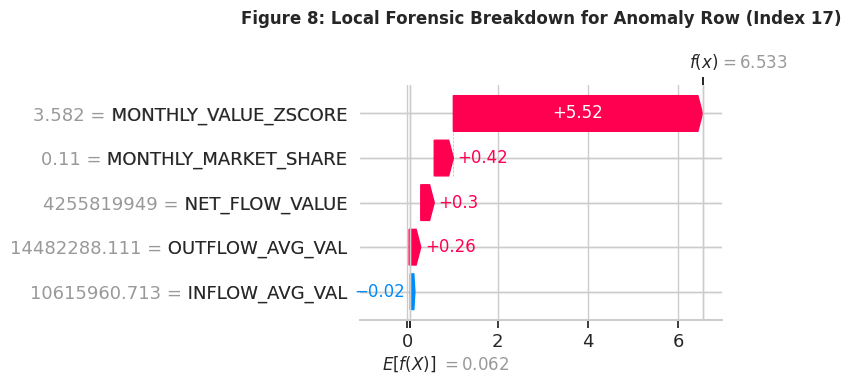

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import shap

print("\nGenerating Local Explanatory Profile for a caught Anomaly...")

# 1. Find indices across the complete dataset where the model successfully caught an anomaly
# Using out-of-fold predictions matched against your ensemble pseudo-labels
anomaly_indices = np.where((y.values == 1) & (oof_predictions == 1))[0]

if len(anomaly_indices) > 0:
    # Pick the first successfully caught anomaly case to dynamically break down
    target_anomaly_idx = anomaly_indices[0]

    plt.figure(figsize=(12, 4))

    # 2. Generate a waterfall plot using the corresponding row index from your global shap_values object
    shap.plots.waterfall(shap_values[target_anomaly_idx], show=False)

    plt.title(f'Figure 8: Local Forensic Breakdown for Anomaly Row (Index {target_anomaly_idx})', fontsize=12, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig('shap_local_anomaly_forensic.png', dpi=300)
    plt.show()
else:
    print("No true positive anomaly instances found in the dataset to generate a local breakdown.")

In [36]:
import xgboost as xgb
import sklearn
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
import joblib
import pandas as pd
import numpy as np
import shap

print("--- Current Colab Environment Versions ---")
print(f"xgboost version       : {xgb.__version__}")
print(f"scikit-learn version  : {sklearn.__version__}")
print(f"joblib version        : {joblib.__version__}")
print(f"pandas version        : {pd.__version__}")
print(f"numpy version         : {np.__version__}")
print(f"shap version          : {shap.__version__}")

print("\n--- Structural Framework Verification ---")
print(f"Isolation Forest Module Location : {IsolationForest.__module__}")
print(f"PCA Module Location              : {PCA.__module__}")

--- Current Colab Environment Versions ---
xgboost version       : 3.3.0
scikit-learn version  : 1.6.1
joblib version        : 1.5.3
pandas version        : 2.2.2
numpy version         : 2.0.2
shap version          : 0.52.0

--- Structural Framework Verification ---
Isolation Forest Module Location : sklearn.ensemble._iforest
PCA Module Location              : sklearn.decomposition._pca


In [37]:
import joblib
import sklearn
import xgboost as xgb
import pandas as pd
import numpy as np
import shap
from datetime import datetime

print("\n[DEPLOYMENT] Packaging all ensemble models and artifacts with metadata...")

MODEL_VERSION = "1.0.0"

# Package EVERY model component directly from active memory
artifact_metadata = {
    "version": MODEL_VERSION,
    "framework_versions": {
        "xgboost": xgb.__version__,
        "scikit-learn": sklearn.__version__,
        "joblib": joblib.__version__,
        "pandas": pd.__version__,
        "numpy": np.__version__,
        "shap": shap.__version__
    },
    "features_required": ['MONTHLY_VALUE_ZSCORE', 'MONTHLY_MARKET_SHARE', 'NET_FLOW_VALUE', 'INFLOW_AVG_VAL', 'OUTFLOW_AVG_VAL'],
    "training_date": datetime.utcnow().strftime("%Y-%m-%d %H:%M:%S UTC"),

    # Core Model Objects - Pointing directly to your active notebook variables
    "isolation_forest_ensemble": isolation_models, # Found from cell [18]
    "pca_model": pca,                               # Found from PCA cell
    "xgboost_classifier": pipeline.named_steps['xgboost']
}

# Export the updated clean package to your Colab environment files
joblib.dump(artifact_metadata, f'bot_fraud_classifier_v{MODEL_VERSION}.pkl')
joblib.dump(le_institution, 'institution_encoder.pkl')
joblib.dump(le_company, 'company_encoder.pkl')

print(f"All deployment artifacts successfully packed under version tag: {MODEL_VERSION}!")


[DEPLOYMENT] Packaging all ensemble models and artifacts with metadata...


/tmp/ipykernel_3314/2676190041.py:25: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "training_date": datetime.utcnow().strftime("%Y-%m-%d %H:%M:%S UTC"),


All deployment artifacts successfully packed under version tag: 1.0.0!


In [38]:
import joblib

# 1. Load the comprehensive production artifact bundle
payload = joblib.load('bot_fraud_classifier_v1.0.0.pkl')

print("=== DEPLOYED MODEL ARTIFACT AUDIT ===")
print(f"Loaded Model Version : {payload['version']}")
print(f"Training Timestamp   : {payload['training_date']}")
print(f"Required Features    : {payload['features_required']}\n")

print("--- Framework Environment Dependencies ---")
for library, version in payload['framework_versions'].items():
    print(f" - {library:<12} : v{version}")

# 2. Extract the operational model layers safely
isolation_ensemble = payload['isolation_forest_ensemble'] # Contains the list of 5 isolation models
pca_layer          = payload['pca_model']                 # Contains the 1 PCA model instance
deployed_xgboost   = payload['xgboost_classifier']        # Contains the trained XGBoost classifier

print(f"\nPipeline Integrity: Extracted {len(isolation_ensemble)} Isolation models, 1 PCA layer, and 1 XGBoost classifier.")
# All layers are ready to accept new processed incoming data rows sequentially!

=== DEPLOYED MODEL ARTIFACT AUDIT ===
Loaded Model Version : 1.0.0
Training Timestamp   : 2026-07-14 11:30:20 UTC
Required Features    : ['MONTHLY_VALUE_ZSCORE', 'MONTHLY_MARKET_SHARE', 'NET_FLOW_VALUE', 'INFLOW_AVG_VAL', 'OUTFLOW_AVG_VAL']

--- Framework Environment Dependencies ---
 - xgboost      : v3.3.0
 - scikit-learn : v1.6.1
 - joblib       : v1.5.3
 - pandas       : v2.2.2
 - numpy        : v2.0.2
 - shap         : v0.52.0

Pipeline Integrity: Extracted 5 Isolation models, 1 PCA layer, and 1 XGBoost classifier.


In [39]:
import io
import joblib
import numpy as np
import pandas as pd
from google.colab import files

print("=== ENSEMBLE PRODUCTION TESTING INTERFACE ===")

# 1. Upload the raw CSV file to be audited
uploaded_file = files.upload()
file_name = list(uploaded_file.keys())[0]
raw_test_df = pd.read_csv(io.BytesIO(uploaded_file[file_name]))

print(f"\nSuccessfully loaded raw test data: '{file_name}' ({raw_test_df.shape[0]} rows)")

# 2. Load your single versioned deployment dictionary file
model_package = joblib.load('bot_fraud_classifier_v1.0.0.pkl')
le_institution = joblib.load('institution_encoder.pkl')
le_company = joblib.load('company_encoder.pkl')

print(f"Loaded Model Package Version: {model_package['version']} (Trained: {model_package['training_date']})")

# Extract our 3 underlying operational model layers out from the bundle payload
isolation_ensemble = model_package['isolation_forest_ensemble']
pca_layer = model_package['pca_model']
deployed_xgboost = model_package['xgboost_classifier']

# 3. Base preprocessing & feature engineering
if 'OUTLOW_VALUE' in raw_test_df.columns:
    raw_test_df = raw_test_df.rename(columns={'OUTLOW_VALUE': 'OUTFLOW_VALUE'})

num_cols = ['INFLOW_VOLUME', 'INFLOW_VALUE', 'OUTFLOW_VOLUME', 'OUTFLOW_VALUE']
for col in num_cols:
    if col in raw_test_df.columns:
        raw_test_df[col] = raw_test_df[col].astype(str).str.replace(',', '', regex=True)
        raw_test_df[col] = pd.to_numeric(raw_test_df[col], errors='coerce').fillna(0)

raw_test_df['REPORTINGDATE'] = pd.to_datetime(raw_test_df['REPORTINGDATE'], errors='coerce')
raw_test_df['MONTH'] = raw_test_df['REPORTINGDATE'].dt.month.fillna(0).astype(int)
raw_test_df['TOTAL_VALUE'] = raw_test_df['INFLOW_VALUE'] + raw_test_df['OUTFLOW_VALUE']
raw_test_df['NET_FLOW_VALUE'] = raw_test_df['INFLOW_VALUE'] - raw_test_df['OUTFLOW_VALUE']

raw_test_df['INFLOW_AVG_VAL'] = np.where(raw_test_df['INFLOW_VOLUME'] > 0, raw_test_df['INFLOW_VALUE'] / raw_test_df['INFLOW_VOLUME'], 0)
raw_test_df['OUTFLOW_AVG_VAL'] = np.where(raw_test_df['OUTFLOW_VOLUME'] > 0, raw_test_df['OUTFLOW_VALUE'] / raw_test_df['OUTFLOW_VOLUME'], 0)

# Calculate relative peer network matrices
market_totals = raw_test_df.groupby('MONTH')['TOTAL_VALUE'].transform('sum')
raw_test_df['MONTHLY_MARKET_SHARE'] = np.where(market_totals > 0, raw_test_df['TOTAL_VALUE'] / market_totals, 0)

means = raw_test_df.groupby('MONTH')['TOTAL_VALUE'].transform('mean')
stds = raw_test_df.groupby('MONTH')['TOTAL_VALUE'].transform('std').replace(0, 1)
raw_test_df['MONTHLY_VALUE_ZSCORE'] = (raw_test_df['TOTAL_VALUE'] - means) / stds

# 4. Generate early-layer features using the extracted models
# Base features required by Isolation Forest and PCA layers
preliminary_features = ['MONTHLY_VALUE_ZSCORE', 'MONTHLY_MARKET_SHARE', 'NET_FLOW_VALUE', 'INFLOW_AVG_VAL', 'OUTFLOW_AVG_VAL']
X_prelim = raw_test_df[preliminary_features].fillna(0.0)

# Layer A: Pass data through all 5 Isolation Forest models to compute the ensemble vote count
if isolation_ensemble is not None:
    all_scores_matrix = np.zeros((len(raw_test_df), len(isolation_ensemble)))
    vote_matrix = np.zeros_like(all_scores_matrix)

    for idx, iso_model in enumerate(isolation_ensemble):
        # Negate sample scores to match original training behavior
        all_scores_matrix[:, idx] = -iso_model.score_samples(X_prelim)
        # Re-apply the top 3% flagging logic threshold used during training
        threshold = np.percentile(all_scores_matrix[:, idx], 97)
        vote_matrix[:, idx] = (all_scores_matrix[:, idx] >= threshold).astype(int)

    raw_test_df['ENSEMBLE_VOTES'] = vote_matrix.sum(axis=1)
else:
    raw_test_df['ENSEMBLE_VOTES'] = 0

# Layer B: Pass data through PCA to calculate the Reconstruction Error metric
if pca_layer is not None:
    transformed_pca = pca_layer.transform(X_prelim)
    reconstructed_pca = pca_layer.inverse_transform(transformed_pca)
    raw_test_df['RECONSTRUCTION_ERROR'] = np.mean((X_prelim.values - reconstructed_pca) ** 2, axis=1)
else:
    raw_test_df['RECONSTRUCTION_ERROR'] = 0.0

# 5. Extract final target feature schema matrix for XGBoost
X_inference = raw_test_df[model_package['features_required']].fillna(0.0)

# 6. Execute final supervised classification prediction
raw_test_df['RISK_PREDICTION'] = deployed_xgboost.predict(X_inference)
raw_test_df['RISK_PROBABILITY'] = deployed_xgboost.predict_proba(X_inference)[:, 1]

# 7. Discovered Results Display
flagged_cases = raw_test_df[raw_test_df['RISK_PREDICTION'] == 1].sort_values(by='RISK_PROBABILITY', ascending=False)

print(f"\n=== AUDIT RESULTS: {len(flagged_cases)} HIGH-RISK ANOMALIES DETECTED VIA ENSEMBLE LAYERS ===")
if not flagged_cases.empty:
    display(flagged_cases[['INSTITUTIONCODE', 'COMPANY', 'MONTH', 'TOTAL_VALUE', 'RISK_PROBABILITY', 'ENSEMBLE_VOTES']].head(15))
else:
    print("Clean audit run. No transactions flagged as anomalies under current rules layout.")

=== ENSEMBLE PRODUCTION TESTING INTERFACE ===


Saving Money_Remittance_transactions_2025.csv to Money_Remittance_transactions_2025 (1).csv

Successfully loaded raw test data: 'Money_Remittance_transactions_2025 (1).csv' (5040 rows)
Loaded Model Package Version: 1.0.0 (Trained: 2026-07-14 11:30:20 UTC)

=== AUDIT RESULTS: 121 HIGH-RISK ANOMALIES DETECTED VIA ENSEMBLE LAYERS ===


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but PCA was fitted without feature names
  warnings.warn(


,INSTITUTIONCODE,COMPANY,MONTH,TOTAL_VALUE,RISK_PROBABILITY,ENSEMBLE_VOTES
78,Bnk-008,Diaspora Data through Swift,1,1648480700,0.994203,5.0
3448,Bnk-009,Diaspora Data through Swift,9,1840829770,0.994203,5.0
2138,Bnk-004,Diaspora Data through Swift,6,1512162569,0.994203,5.0
1768,Bnk-009,Diaspora Data through Swift,5,1437702818,0.992672,5.0
38,Bnk-004,Diaspora Data through Swift,1,1654385706,0.992299,5.0
888,Bnk-005,Diaspora Data through Swift,3,1604028180,0.992299,5.0
1758,Bnk-008,Diaspora Data through Swift,5,1482786044,0.992299,5.0
498,Bnk-008,Diaspora Data through Swift,2,1319895984,0.992299,5.0
478,Bnk-006,Diaspora Data through Swift,2,1771722985,0.992299,5.0
2978,Bnk-004,Diaspora Data through Swift,8,1409516784,0.992299,5.0
